# Project Goal

**Background and Motivation:** The stock market reflects both corporate performance and broader economic events, with price movements and trading volumes revealing patterns of resilience and volatility. This project analyzes leading companies from 2020–2024, a period that includes the COVID-19 crash and subsequent recovery. Through visualizations of trading volumes, closing prices, and year-over-year changes, the study highlights sector-specific behavior, market shocks, and trends in stock performance. The goal is to provide insights into how different companies respond to market events and guide investment decisions.

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import math 

# 1) Loading Dataset
I will be using the Market Champions: Leading Stocks Dataset from Kaggle. It is retrieved from, https://www.kaggle.com/datasets/jijagallery/industry-leaders-performance-dataset?resource=download

In [174]:
stocks = pd.read_csv("Stock Portfolio.csv")

print('\nData Preview:')
display(stocks.head())
display(stocks.info())


Data Preview:


,Date,Ticker,Open,High,Low,Close,Volume
0,2020-01-02 00:00:00+00:00,AAPL,74.059998,75.150002,73.797501,75.087502,135480400
1,2020-01-03 00:00:00+00:00,AAPL,74.287498,75.144997,74.125000,74.357498,146322800
2,2020-01-06 00:00:00+00:00,AAPL,73.447502,74.989998,73.187500,74.949997,118387200
3,2020-01-07 00:00:00+00:00,AAPL,74.959999,75.224998,74.370003,74.597504,108872000
4,2020-01-08 00:00:00+00:00,AAPL,74.290001,76.110001,74.290001,75.797501,132079200


<class 'pandas.DataFrame'>
RangeIndex: 26397 entries, 0 to 26396
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    26397 non-null  str    
 1   Ticker  26397 non-null  str    
 2   Open    26397 non-null  float64
 3   High    26397 non-null  float64
 4   Low     26397 non-null  float64
 5   Close   26397 non-null  float64
 6   Volume  26397 non-null  int64  
dtypes: float64(4), int64(1), str(2)
memory usage: 2.1 MB


None

# 2) Exploratory Data Analysis

I will be examining top 10 stocks according to the volume traded for this project.

In [175]:
print('\nShape:')
print(stocks.shape)
stocks.describe(include='all')


Shape:
(26397, 7)


,Date,Ticker,Open,High,Low,Close,Volume
count,26397,26397,26397.000000,26397.000000,26397.000000,26397.000000,2.639700e+04
unique,1257,21,NaN,NaN,NaN,NaN,NaN
top,2020-01-02 00:00:00+00:00,AAPL,NaN,NaN,NaN,NaN,NaN
freq,21,1257,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,243.676662,246.258898,241.049357,243.713391,3.780222e+07
std,NaN,NaN,209.699844,211.749150,207.472183,209.647796,1.038234e+08
min,NaN,NaN,5.002500,5.248500,4.517000,4.910000,1.733000e+05
25%,NaN,NaN,112.680000,114.129997,111.050003,112.760002,3.059400e+06
50%,NaN,NaN,169.529999,171.270004,168.020004,169.750000,7.758900e+06
75%,NaN,NaN,289.160004,292.070007,285.619995,289.160004,2.295810e+07


In [176]:
stocks['Ticker'].value_counts()

Ticker
AAPL     1257
MSFT     1257
GOOGL    1257
AMZN     1257
NVDA     1257
TSM      1257
JNJ      1257
UNH      1257
LLY      1257
XOM      1257
NEE      1257
JPM      1257
V        1257
BLK      1257
WMT      1257
COST     1257
PG       1257
CAT      1257
HON      1257
CRM      1257
ASML     1257
Name: count, dtype: int64

In [177]:
# Clean the ticker to remove empty spaces and covert it into a string object
stocks['Ticker'] = stocks['Ticker'].str.strip()

# remove na values
stocks_clean = stocks.dropna(subset=['Open', 'High', 'Low', 'Close', 'Volume']).copy() 

# Extract only the top 10 stocks by volume of shares traded
top_10_stocks = stocks_clean.groupby('Ticker')['Volume'].sum().nlargest(10)
stocks_clean = stocks_clean[stocks_clean['Ticker'].isin(top_10_stocks.index)]

# Covert date format 
stocks_clean['Date'] = pd.to_datetime(stocks_clean['Date'], errors='coerce')

# 3) Visualisation

## 1) Dot Plot

- Understanding when trading activity peaks can help investors anticipate market momentum and plan their strategies.
- We will be visualising the trading volume across each months for year 2020 to year 2024.
- This allows us to examine which month has the busiest trading activity.

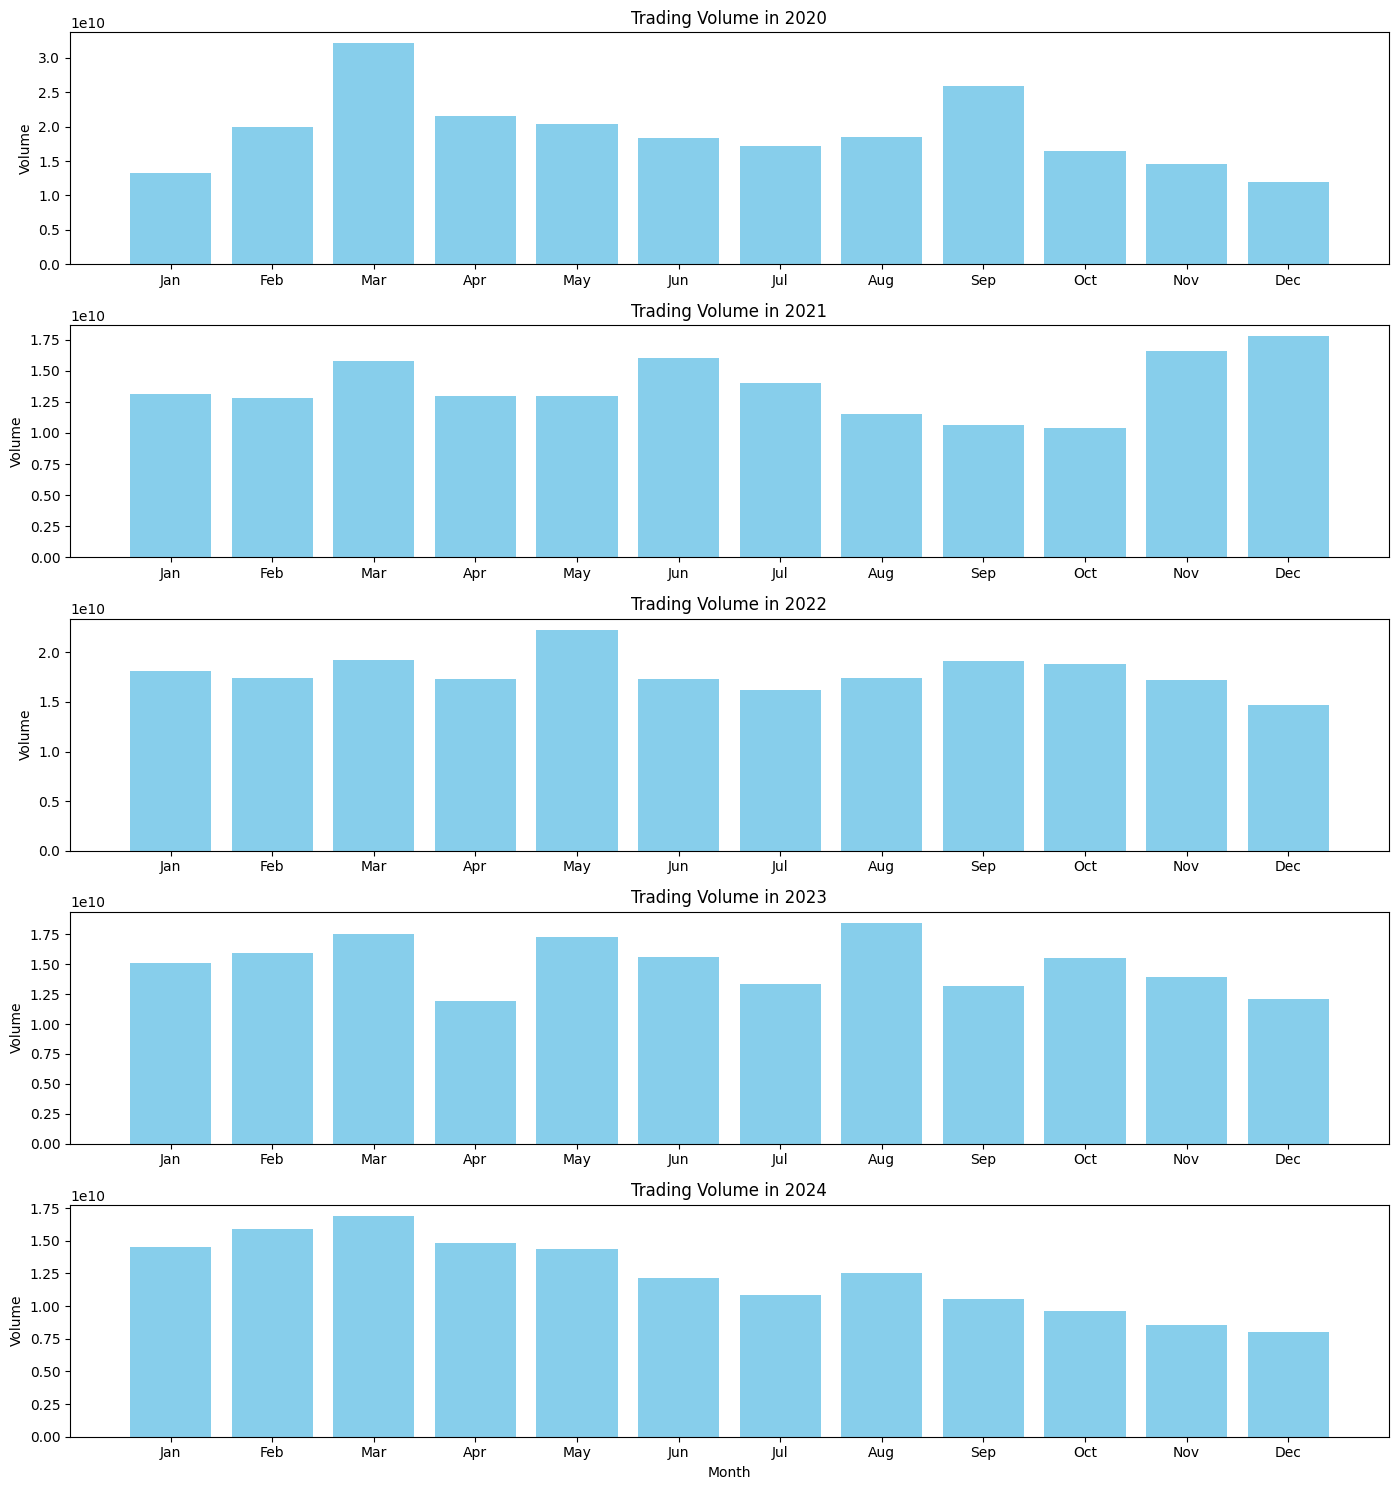

In [183]:
# Extract year and month
stocks_clean['Year'] = stocks_clean['Date'].dt.year
stocks_clean['Month'] = stocks_clean['Date'].dt.month

# Group by year and month, sum of volumn
monthly_vol = stocks_clean.groupby(['Year', 'Month'])['Volume'].sum().reset_index()

# create subplots for each year
years = monthly_vol['Year'].unique()
fig, axes = plt.subplots(len(years), 1, figsize=(14, 3*len(years)), sharex=False)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

for i, year in enumerate(sorted(years)):
    data = monthly_vol[monthly_vol['Year'] == year]
    axes[i].bar(data['Month'], data['Volume'], color='skyblue')
    axes[i].set_title(f'Trading Volume in {year}')
    axes[i].set_ylabel('Volume')
    axes[i].set_xticks(range(1,13))
    axes[i].set_xticklabels(month_labels)

plt.xlabel('Month')
plt.tight_layout()
plt.show()

- March consistently sees the highest trading volume, suggesting increased market activity in early spring.
- 2020 stands out with an exceptionally high peak, hitting 4.0 on the volume scale, while other years typically range between 2.0 and 3.0.
- December is usually average, but 2021 saw an unusual spike, indicating a sudden surge in market interest.
- Overall, trading slows toward the end of the year, with volumes tapering in November and December across most years.

## 2) Sloped Chart 

- The COVID-19 pandemic triggered one of the sharpest market crashes in history. This chart shows how stock prices shifted from pre-pandemic levels to the market bottom.
- The sloped chart shows stock price changes from pre-COVID levels (19 Feb 2020) to the market bottom (23 Mar 2020).

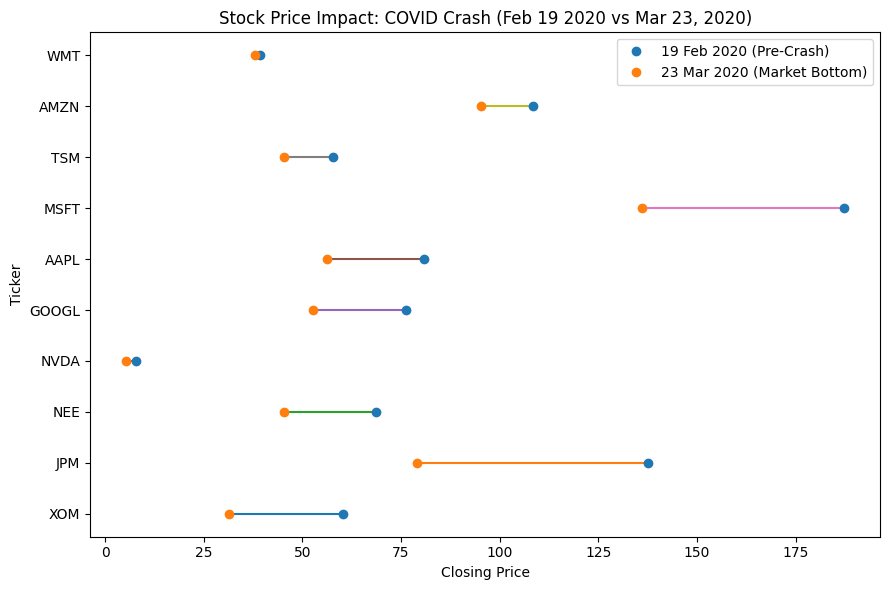

In [179]:
# Filter for the two key dates
stocks_clean['Date_only'] = stocks_clean['Date'].dt.date
import datetime
event_dates = [datetime.date(2020, 2, 19), datetime.date(2020, 3, 23)]
price_change = stocks_clean[stocks_clean['Date_only'].isin(event_dates)]

# create pivot table
piv = (price_change.pivot(index = 'Ticker', columns = 'Date_only', values = 'Close').dropna())

# Sort by biggest drop
piv['price_change'] = ((piv[datetime.date(2020, 3, 23)] - piv[datetime.date(2020, 2, 19)])/piv[datetime.date(2020, 2, 19)]) * 100

piv2 = piv.sort_values('price_change')

# paired dot plot
yy = np.arange(len(piv2))

plt.figure(figsize=(9,6))

for i, t in enumerate(piv2.index):
    plt.plot([piv2.loc[t, datetime.date(2020, 2, 19)], piv2.loc[t, datetime.date(2020, 3, 23)]], [yy[i], yy[i]], '-')

plt.plot(piv2[datetime.date(2020, 2, 19)].values, yy, 'o', label='19 Feb 2020 (Pre-Crash)')
plt.plot(piv2[datetime.date(2020, 3, 23)].values, yy, 'o', label='23 Mar 2020 (Market Bottom)')

plt.yticks(yy, piv2.index.tolist())
plt.xlabel("Closing Price")
#plt.xscale("log")
plt.ylabel("Ticker")
plt.title(f"Stock Price Impact: COVID Crash (Feb 19 2020 vs Mar 23, 2020)")

plt.legend()
plt.tight_layout()
plt.show()

- COVID-19 caused a sharp, widespread market decline.
- The chart shows a clear sector-based vulnerability: energy and travel-related stocks declined sharply, whereas consumer staples were less affected.
- Walmart(WMT) and Amazon(AMZN) were the most resilient, losing the least value, while energy giant Exxon Mobil(XOM) experienced the steepest decline.
- Other tech leaders like Microsoft (MSFT), Apple (AAPL), and Google (GOOGL) faced moderate losses, reflecting market uncertainty but strong fundamentals.
- Utilities and financials like NextEra Energy (NEE) and JPMorgan (JPM) also fell sharply.
- Overall, the chart highlights sector-specific vulnerability: essential retail and e-commerce were defensive, tech showed moderate resilience, and energy and financials were highly exposed to the shock.

## 3) Small Multiples Chart

- This chart allows us to observe how each stock’s price evolved over time, making it easier to spot growth trends, crashes, or periods of stability across the market.

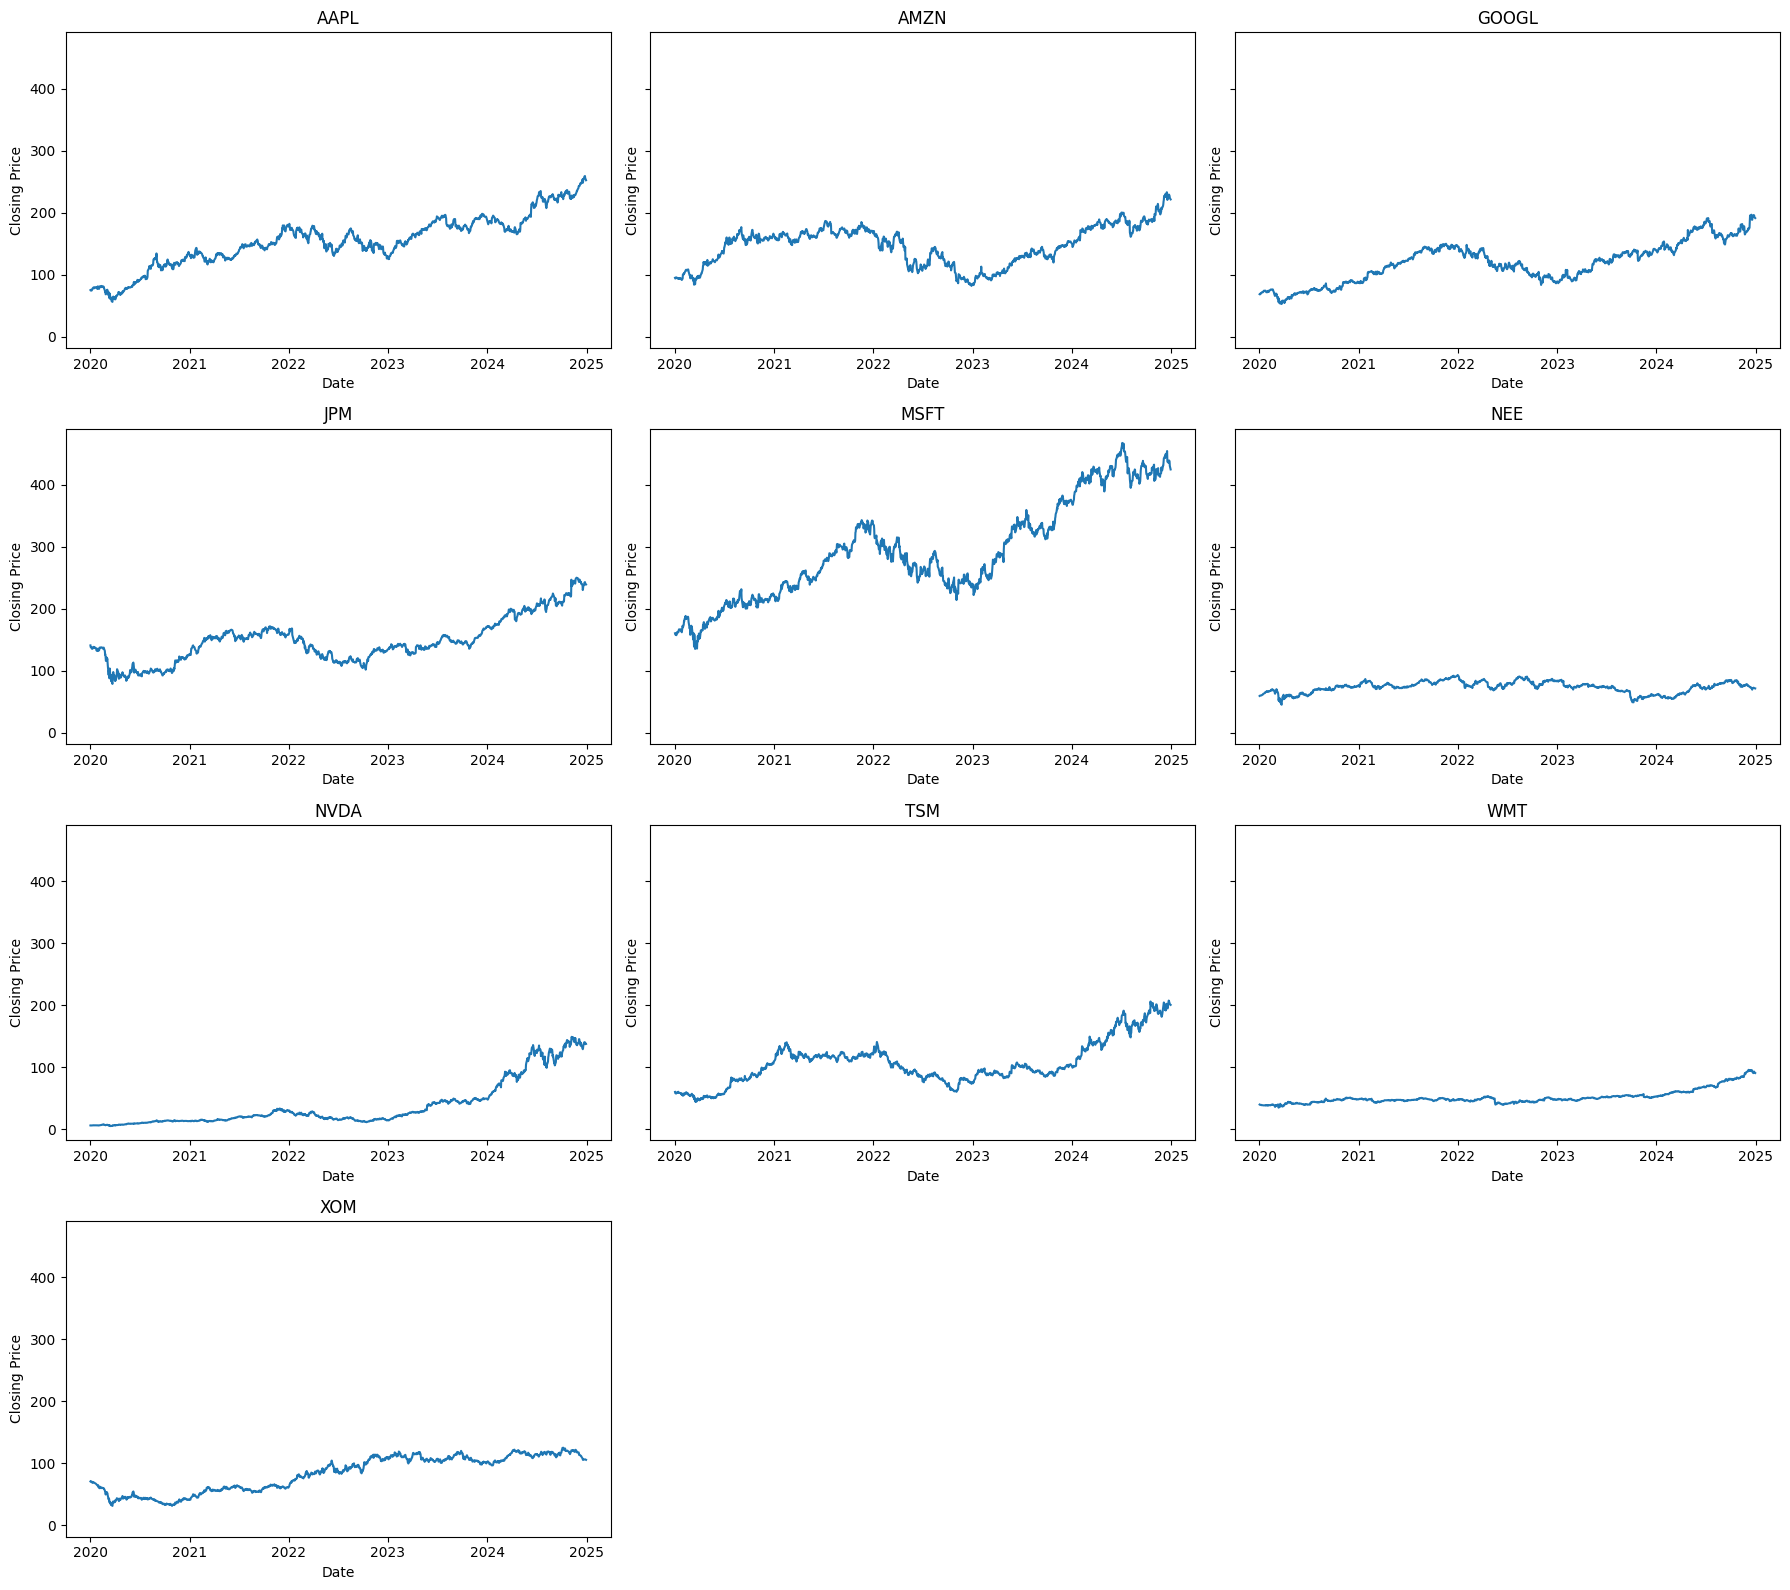

In [180]:
# Sort values (important for line plots)
stocks_clean = stocks_clean.sort_values(['Ticker', 'Date'])

# Get unique tickers
tickers = sorted(stocks_clean['Ticker'].unique())

# Grid setup
n_cols = 3
n_rows = (len(tickers) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, 
                         figsize=(6*n_cols, 4*n_rows), 
                         sharex=False, 
                         sharey=True)

axes = axes.flatten()

for i, ticker in enumerate(tickers):
    data = stocks_clean[stocks_clean['Ticker'] == ticker]
    
    axes[i].plot(data['Date'], data['Close'])
    axes[i].set_title(ticker)
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Closing Price')

# Turn off unused subplots
for j in range(len(tickers), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


- Stocks are generally trending up
- AAPL, AMZN, and GOOGL show gradual, steady growth, reflecting sustained demand and resilience.
- In contrast, NEE, WMT, and XOM remain relatively flat, indicating stable or defensive positioning.
- MSFT stands out with the most obvious fluctuations, capturing both rapid growth and sensitivity to market events.
- Across all stocks, notable dips around March 2020 reflect the market-wide impact of COVID-19, illustrating both sector-specific trends and systemic shocks.

## 4) Normalized Year-over-Year (YoY) % change chart
   
- Shows annual growth or decline for each stock relative to the prior year.
- Highlights which stocks grew consistently, which were volatile, and which lagged behind.
- Normalization allows you to compare different price levels on the same scale.

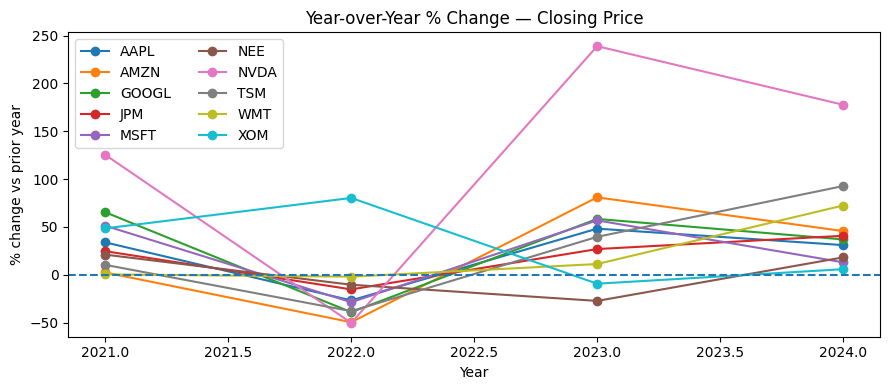

In [182]:
pct = year_end.pivot(index='Year',
                     columns='Ticker',
                     values='YoY_Close_%')

plt.figure(figsize=(9,4))

for t in pct.columns:
    s = pct[t].dropna()
    plt.plot(s.index, s.values, marker='o', label=t)

plt.axhline(0, linestyle='--')
plt.xlabel("Year")
plt.ylabel("% change vs prior year")
plt.title("Year-over-Year % Change — Closing Price")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()

- This normalized YoY % change chart reveals stark differences in stock performance across sectors.
- NVDA shows extreme swings, with a steep decline in 2022, a sharp rebound in 2023, and a modest dip in 2024, illustrating high volatility in the semiconductor sector.
- In contrast, XOM moves opposite the broader market, rising in 2022 while most tech and consumer stocks fell, reflecting energy market dynamics.
- NEE demonstrates defensive behavior, remaining relatively stable during 2022.
- WMT remains largely stable through market fluctuations, with steady growth emerging after 2022, highlighting the resilience of essential retail even amid volatile economic conditions.
- Overall, the chart emphasizes how market shocks and recoveries affect sectors differently, highlighting both volatility and resilience over time.

# 4) Conclusion

Among all visualizations, the sloped chart best supports the comparison question: how did stock prices respond to a specific market shock? Its design directly connects pre- and post-event values, making the magnitude and direction of change immediately visible for each stock. Sorting by percentage change further emphasizes differences, while using lines for individual stocks allows viewers to compare extremes and patterns at a glance.

Other charts, like the small multiples or YoY normalized line chart, are excellent for observing trends over time but require more interpretation to identify relative changes across stocks. The dot plot reveals volume patterns but does not show price change comparisons directly. Therefore, the sloped chart provides the clearest, most intuitive view of comparative stock responses to a key event.